<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict, defaultdict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellsweep.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping, CellBender_Fig2_to_Immune_All_Low_celltype_mapping, CellTypistHigh_to_ImmuneMajor, CellTypistLow_to_ImmuneMajor
from cellsweep import denoise_count_matrix
from cellsweep.simulation import simulate_cells
import cellsweep.utils as cs_utils
import scipy.sparse as sp

cellsweep_dir = os.path.dirname(os.path.abspath(""))

# Compare technologies

In [3]:
dataset_name = "parse_10x"  # options: parse_10x, smartseq_10x
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = True  # overwrite existing files
threads = 8  # for cellsweep and CellBender (if use_cuda=False)

In [ ]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

adata_10x_url, adata_parse_url, adata_smartseq_url = None, None, None
adata_path_raw_10x = os.path.join(data_dir, "adata_10x_raw.h5ad")
adata_path_parse = os.path.join(data_dir, "adata_parse_raw.h5ad")
adata_path_smartseq = os.path.join(data_dir, "adata_smartseq_raw.h5ad")

technology_to_adata_raw = {}
if dataset_name == "parse_10x":
    technologies = ["10x", "parse"]
    
    adata_10x_url = "https://caltech.box.com/shared/static/g03q46wpr5uj81gqp0dh3dyy02zw200e.h5ad"
    adata_parse_url = "https://caltech.box.com/shared/static/4bai2qfe7xk2956ug1t7bpdw0q6tspie.h5ad"

    if not os.path.exists(adata_path_raw_10x):
        !wget -O {adata_path_raw_10x} {adata_10x_url}

    if not os.path.exists(adata_path_parse):
        !wget -O {adata_path_parse} {adata_parse_url}

    technology_to_adata_raw["10x"] = ad.read_h5ad(adata_path_raw_10x)
    technology_to_adata_raw["parse"] = ad.read_h5ad(adata_path_parse)

    technology_to_umi_cutoff = {
        "10x": 300,
        "parse": 200,
    }
    leiden_resolution = 1.0

elif dataset_name == "smartseq_10x":
    technologies = ["10x", "smartseq"]
    
    adata_10x_url = ""
    adata_smartseq_url = ""

    if not os.path.exists(adata_path_raw_10x):
        !wget -O {adata_path_raw_10x} {adata_10x_url}
    
    if not os.path.exists(adata_path_smartseq):
        !wget -O {adata_path_smartseq} {adata_smartseq_url}

    technology_to_adata_raw["10x"] = ad.read_h5ad(adata_path_raw_10x)
    technology_to_adata_raw["smartseq"] = ad.read_h5ad(adata_path_smartseq)

    technology_to_umi_cutoff = {
        "10x": None,
        "smartseq": None,
    }
    leiden_resolution = 1.0
else:
    raise ValueError(f"dataset_name {dataset_name} not recognized.")

technology0, technology1 = technologies[0], technologies[1]

## Knee plot - use this output to estimate umi_cutoff

Processing technology: 10x
Processing technology: parse


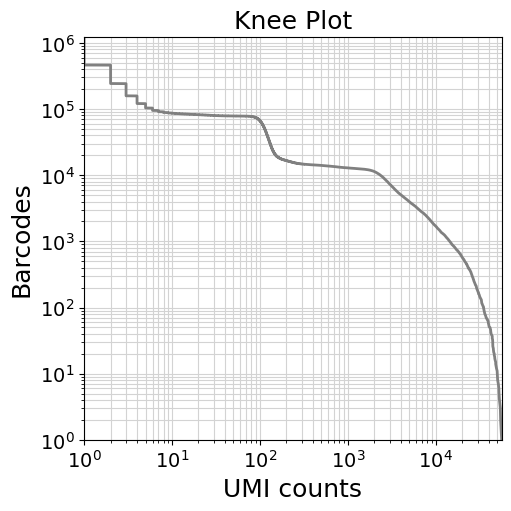

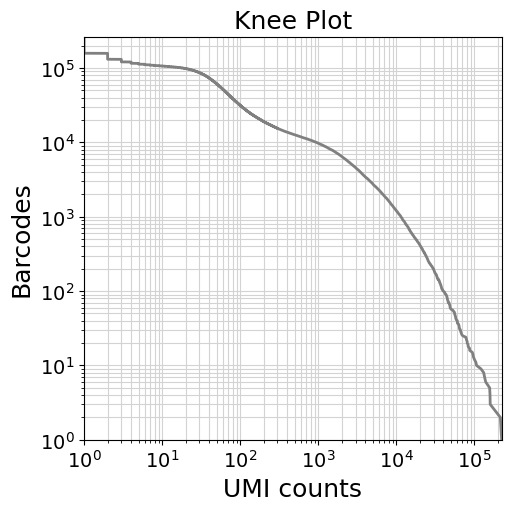

In [5]:
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Processing technology: {technology}")
    _ = cs_utils.knee_plot(adata_raw, transpose=True, out_path=os.path.join(out_dir, f"knee_plot_{technology}.png"))

In [6]:
# technology_to_umi_cutoff = {}   #!!! update

In [7]:
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Inferring empty droplets for technology: {technology}")
    umi_cutoff = technology_to_umi_cutoff[technology]
    adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()
    technology_to_adata_raw[technology] = adata_raw

Inferring empty droplets for technology: 10x
Inferring empty droplets for technology: parse


## cellsweep

In [12]:
technology_to_adata_cellsweep = {}
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Denoising counts for technology: {technology}")
    adata_path_cellsweep = os.path.join(out_dir, f"adata_cellsweep_{technology}.h5ad")
    cellsweep_log_file = os.path.join(out_dir, f"cellsweep_{technology}.log")
    
    if not os.path.exists(adata_path_cellsweep) or overwrite:
        adata = adata_raw.copy()
        if "celltype" not in adata.obs.columns:
            adata_processed_tmp = adata[~adata.obs["is_empty"]].copy()
            adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=None, min_cells=None, max_mt_percentage=None, n_top_genes=2000, n_pcs=50, n_neighbors=15, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata.obs["celltype"] = adata_processed_tmp.obs["leiden"].reindex(adata.obs.index).astype(str).replace("nan", "empty").astype("category")
        adata_cellsweep = denoise_count_matrix(adata, init_alpha = 0.9, beta = 0.1, adata_out=adata_path_cellsweep, freeze_ambient_profile=True, max_iter=500, empty_droplet_method="threshold", threads=threads, verbose=verbose, log_file=cellsweep_log_file)
    else:
        adata_cellsweep = ad.read_h5ad(adata_path_cellsweep)
    
    adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()
    
    technology_to_adata_cellsweep[technology] = adata_cellsweep

Denoising counts for technology: 10x


11:59:01 - INFO - Adata initial shape: (14777, 34183)
11:59:01 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
11:59:02 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
11:59:02 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like cl

Number of celltypes: 16
Logging to /home/jrich/Desktop/cellsweep/notebooks/output/parse_10x/cellsweep_10x.log


11:59:27 - DEBUG - Number of parameters in the cellsweep model: 561,706 (alpha: 14,777, beta: 1, p_k: 546,928)
11:59:27 - INFO - Inferring the gene ambient profile from empty droplets.
11:59:27 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
11:59:30 - INFO - Performing Sparse EM with 8 Numba thread(s)
11:59:39 - INFO - EM Iter   1: ll=-538.086 min_alpha=0.2540 mean_alpha=0.8735 median_alpha=0.8758 max_alpha=0.9335 beta=0.103515
11:59:43 - INFO - EM Iter   2: ll=-535.543 min_alpha=0.0121 mean_alpha=0.8143 median_alpha=0.8222 max_alpha=0.9666 beta=0.104020
11:59:44 - INFO - EM Iter   3: ll=-533.789 min_alpha=0.0015 mean_alpha=0.7504 median_alpha=0.7629 max_alpha=0.9870 beta=0.103013
11:59:44 - INFO - EM Iter   4: ll=-532.653 min_alpha=0.0002 mean_alpha=0.6970 median_alpha=0.7095 max_alpha=0.9954 beta=0.101457
11:59:45 - INFO - EM Iter   5: ll=-531.950 min_alpha=0.0000 mean_alpha=0.6543 median_alpha=0.6648 max_alpha=0.9984 beta=0.099

Denoising counts for technology: parse


12:01:08 - INFO - Adata initial shape: (19053, 34183)
12:01:08 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
12:01:10 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
12:01:10 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like cl

Number of celltypes: 11
Logging to /home/jrich/Desktop/cellsweep/notebooks/output/parse_10x/cellsweep_parse.log


12:01:23 - DEBUG - Number of parameters in the cellsweep model: 395,067 (alpha: 19,053, beta: 1, p_k: 376,013)
12:01:23 - INFO - Inferring the gene ambient profile from empty droplets.
12:01:23 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
12:01:24 - INFO - Performing Sparse EM with 8 Numba thread(s)
12:01:27 - INFO - EM Iter   1: ll=-1932.092 min_alpha=0.7160 mean_alpha=0.9120 median_alpha=0.9062 max_alpha=0.9449 beta=0.101207
12:01:28 - INFO - EM Iter   2: ll=-1929.473 min_alpha=0.5065 mean_alpha=0.9054 median_alpha=0.9019 max_alpha=0.9549 beta=0.101414
12:01:28 - INFO - EM Iter   3: ll=-1928.349 min_alpha=0.3800 mean_alpha=0.8970 median_alpha=0.8973 max_alpha=0.9639 beta=0.101266
12:01:28 - INFO - EM Iter   4: ll=-1927.454 min_alpha=0.2999 mean_alpha=0.8880 median_alpha=0.8925 max_alpha=0.9713 beta=0.100897
12:01:28 - INFO - EM Iter   5: ll=-1926.748 min_alpha=0.2445 mean_alpha=0.8788 median_alpha=0.8868 max_alpha=0.9768 beta=

## Analysis

### Raw vs cellsweep knee plot, scatterplots

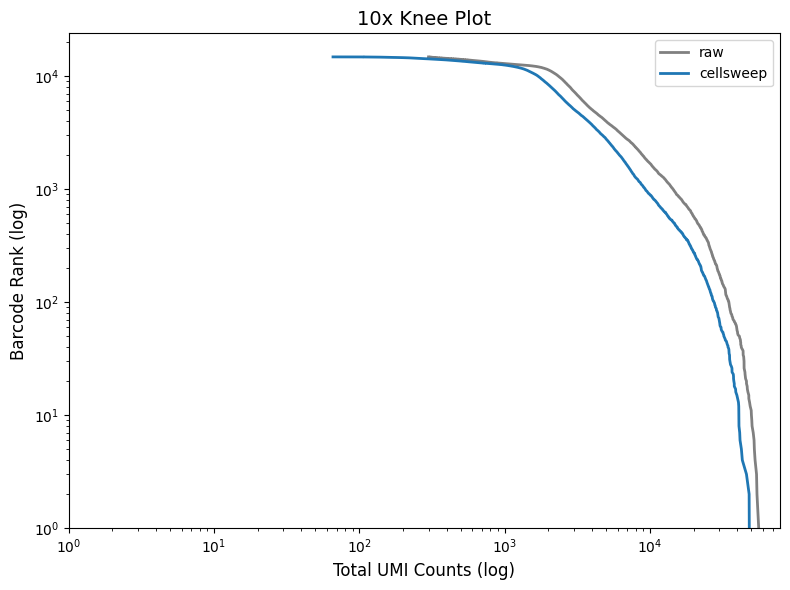

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


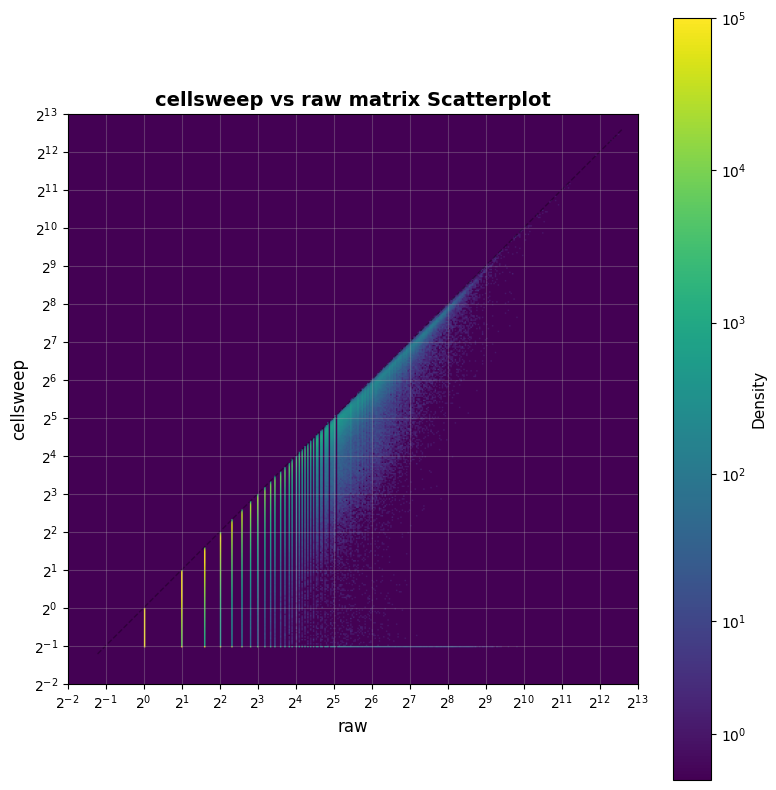

Creating scatterplot...
Calculating scatterplot...


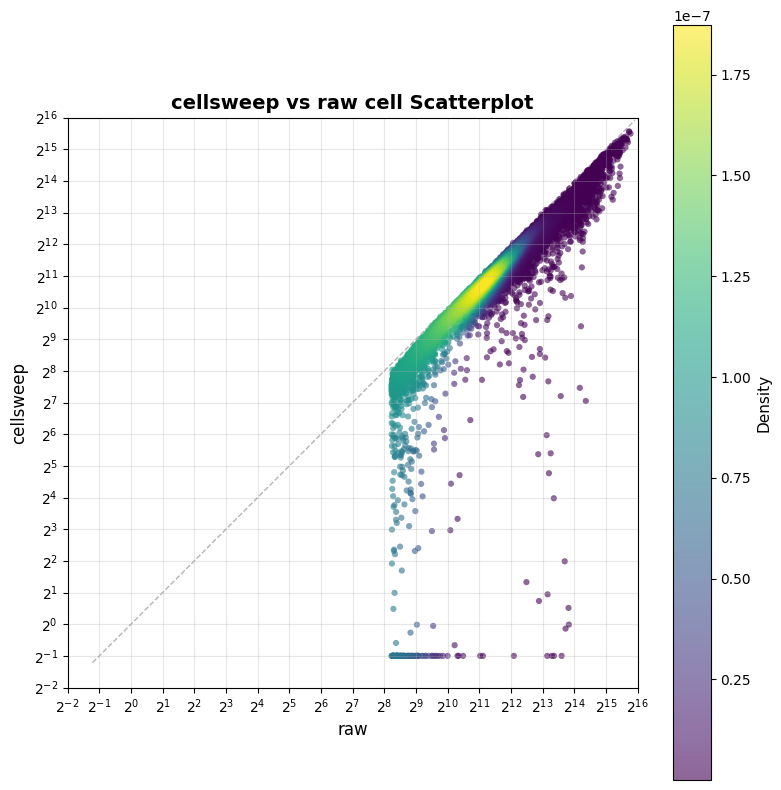

Creating scatterplot...
Calculating scatterplot...


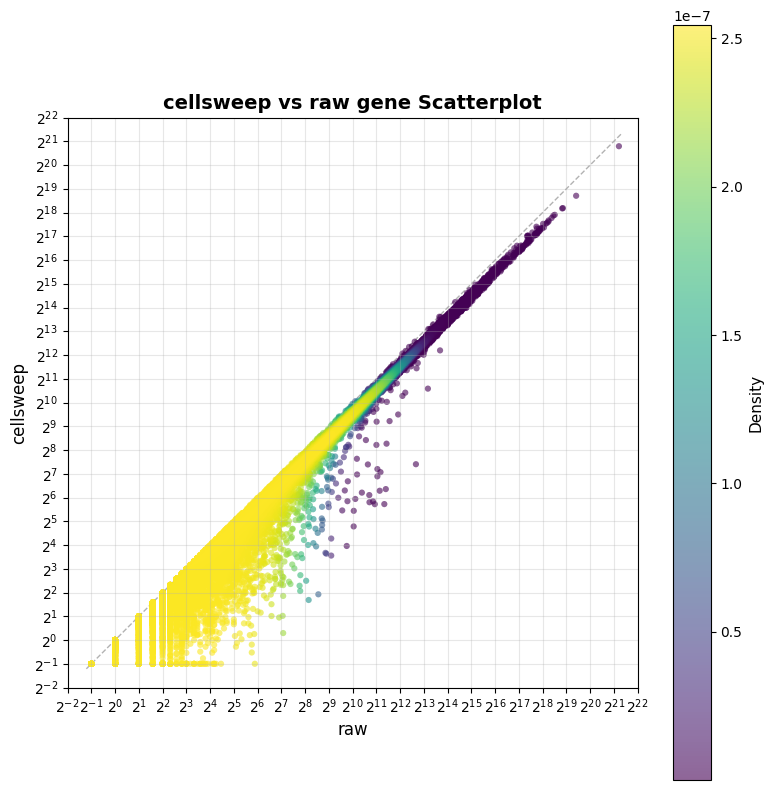

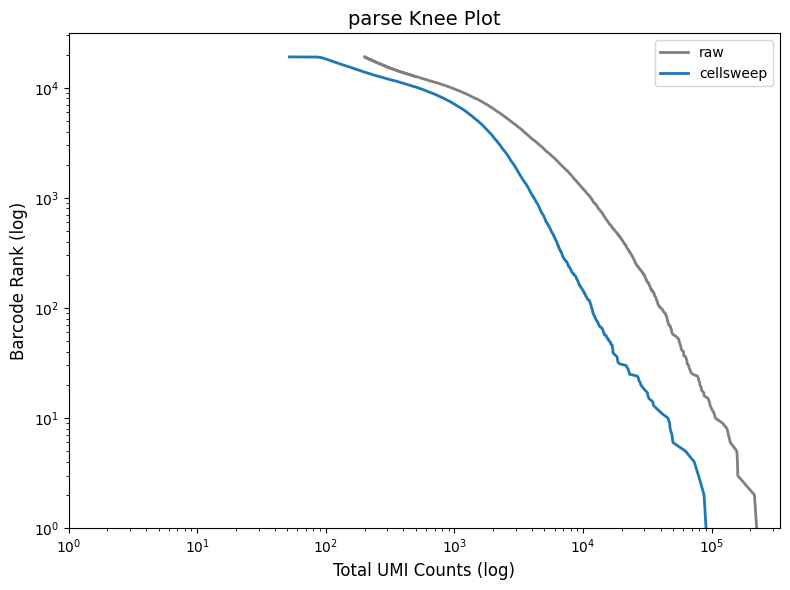

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


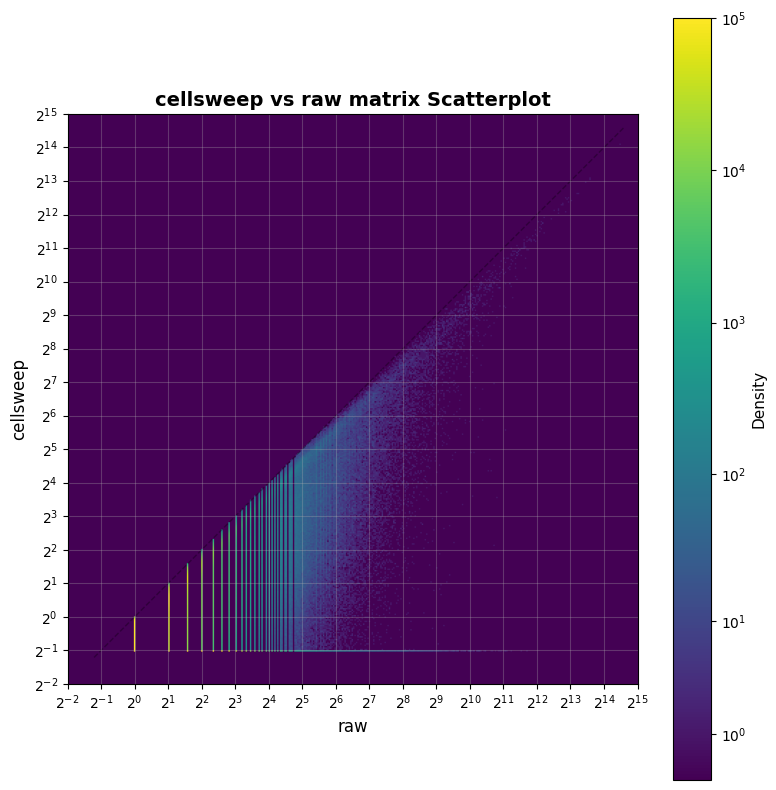

Creating scatterplot...
Calculating scatterplot...


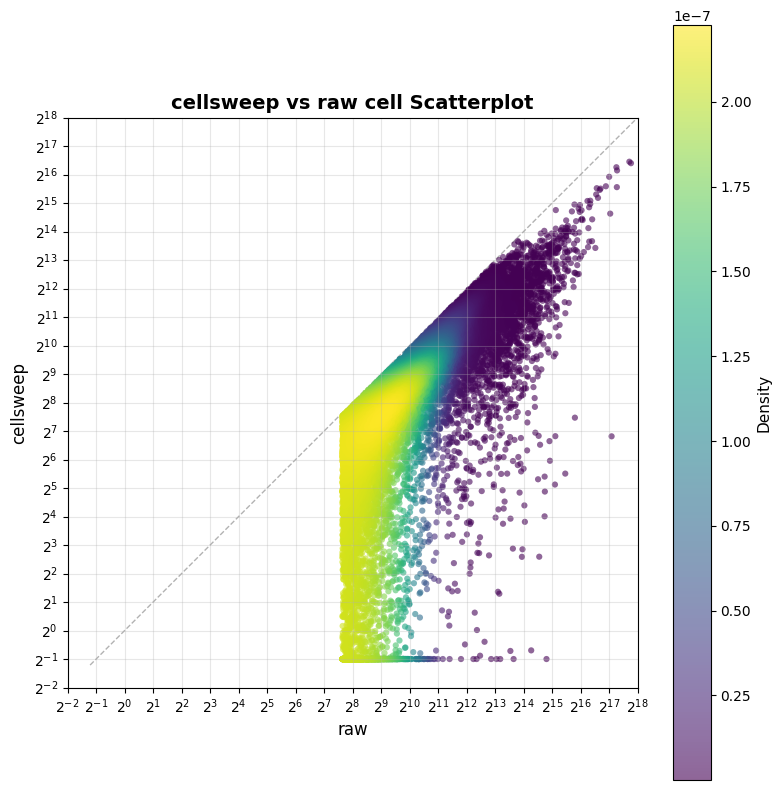

In [ ]:
for technology in technologies:
    print(f"Technology: {technology}")
    adata_raw = technology_to_adata_raw[technology]
    adata_cellsweep = technology_to_adata_cellsweep[technology]
    cs_utils.plot_knee_multi([adata_raw, adata_cellsweep], labels=["raw", "cellsweep"], title=f"{technology} Knee Plot", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, f"{technology}_knee_plot.png"))

    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot matrix {technology}", out_path=os.path.join(out_dir, f"{technology}_matrix_expression_scatterplot.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot cell {technology}", out_path=os.path.join(out_dir, f"{technology}_cell_expression_scatterplot.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot gene {technology}", out_path=os.path.join(out_dir, f"{technology}_gene_expression_scatterplot.png"), show=True)

### Ambient hat per gene scatterplot across technologies

In [ ]:
cs_utils.plot_matrix_scatterplot(technology_to_adata_cellsweep[technology0].var["ambient_hat"], technology_to_adata_cellsweep[technology1].var["ambient_hat"], point_type="custom", density_type="scatter_with_kde", scale="log", x_axis=technology0, y_axis=technology1, out_path=os.path.join(out_dir, f"{technology0}_vs_{technology1}_ambient_hat_scatterplot.png"), show=True)

### Ambient fraction per cell histogram across technologies

In [ ]:
cs_utils.plot_multi_histogram(technology_to_adata_cellsweep[technology0].obs, technology_to_adata_cellsweep[technology1].obs, plotting_column="cell_ambient_fraction", df1_name=technology0, df2_name=technology1, out_path=os.path.join(out_dir, f"{technology0}_vs_{technology1}_cell_empty_fraction_scatterplot.png"), show=True)